# Preparación de tazas rotas sintéticas para evaluar Pix2Vox++

Este notebook genera un conjunto externo de **tazas rotas sintéticamente** a partir de los modelos `.ply` originales de ShapeNet.

El objetivo es evaluar si el modelo **Pix2Vox++/A entrenado previamente** generaliza correctamente a geometrías de tazas parcialmente destruidas. Las roturas no pretenden reproducir físicamente una fractura real, sino introducir una variabilidad geométrica controlada y suficientemente amplia.

El flujo será:

1. Cargar las tazas originales.
2. Generar roturas sintéticas aleatorias.
3. Visualizar una muestra de las roturas.
4. Guardar las geometrías rotas.
5. Renderizar las cinco vistas utilizadas por el experimento de Pix2Vox++: `00`, `05`, `10`, `14` y `19`.
6. Visualizar las cinco vistas.
7. Crear el ground truth voxel de cada taza rota.
8. Evaluar el checkpoint de Pix2Vox++ sin realizar nuevo entrenamiento.
9. Calcular IoU, Dice, Chamfer Distance y F-score.
10. Analizar la capacidad de generalización según el tipo y severidad de la rotura.


## 1. Configuración y localización de las tazas

En esta primera sección se prepara el entorno de trabajo y se localizan los modelos `.ply` originales de la categoría **mugs (03797390)** de ShapeNet.

No se modifica todavía ninguna geometría. Únicamente comprobamos que las tazas originales están disponibles y definimos las carpetas donde se almacenarán posteriormente las roturas sintéticas, los renders y los ground truth.


In [ ]:
%pip -q install -U pip

%pip -q install open3d==0.19.0
%pip -q install trimesh scipy pandas matplotlib plotly imageio blenderproc scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 107.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 109, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 102, in _inner_run
    return self.run(options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 106, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 541, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/py

In [ ]:
# ============================================================
# 1. CONFIGURACIÓN Y LOCALIZACIÓN
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import trimesh
import open3d as o3d

# ------------------------------------------------------------
# Semilla para reproducibilidad
# ------------------------------------------------------------

SEMILLA = 2026
random.seed(SEMILLA)
np.random.seed(SEMILLA)

# ------------------------------------------------------------
# Rutas
# ------------------------------------------------------------

RUTA_BASE = Path("/content/drive/MyDrive/Datos_E2_E3")

RUTA_ORIGINALES = RUTA_BASE / "General/Shapenet_limpias/03797390"

RUTA_SALIDA = RUTA_BASE / "General/Shapenet_sintetic_rotas_v2/03797390"

RUTA_PLY = RUTA_SALIDA / "ply"
RUTA_BINVOX = RUTA_SALIDA / "binvox"
RUTA_RENDERS = RUTA_SALIDA / "renders_5v"
RUTA_METADATA = RUTA_SALIDA / "metadata"

for ruta in [RUTA_SALIDA, RUTA_PLY, RUTA_BINVOX,
             RUTA_RENDERS, RUTA_METADATA]:
    ruta.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Configuración de Pix2Vox++
# ------------------------------------------------------------

VISTAS_5 = [0, 5, 10, 14, 19]

ANCHO_IMAGEN = 224
ALTO_IMAGEN = 224
RESOLUCION_VOXEL = 32

# ------------------------------------------------------------
# Localizar tazas
# ------------------------------------------------------------

archivos_ply = sorted(RUTA_ORIGINALES.glob("*.ply"))

print("=" * 60)
print("CONFIGURACIÓN — TAZAS ROTAS SINTÉTICAS")
print("=" * 60)

print(f"Tazas originales encontradas: {len(archivos_ply)}")
print(f"Carpeta de entrada: {RUTA_ORIGINALES}")
print(f"Carpeta de salida:  {RUTA_SALIDA}")
print(f"Vistas Pix2Vox++:   {VISTAS_5}")

if len(archivos_ply) == 0:
    raise RuntimeError("No se encontraron archivos .ply.")

print("\nPrimeras tazas:")
for p in archivos_ply[:5]:
    print(" •", p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CONFIGURACIÓN — TAZAS ROTAS SINTÉTICAS
Tazas originales encontradas: 172
Carpeta de entrada: /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_limpias/03797390
Carpeta de salida:  /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_sintetic_rotas_v2/03797390
Vistas Pix2Vox++:   [0, 5, 10, 14, 19]

Primeras tazas:
 • 1038e4eac0e18dcce02ae6d2a21d494a.ply
 • 10f6e09036350e92b3f21f1137c3c347.ply
 • 128ecbc10df5b05d96eaf1340564a4de.ply
 • 1305b9266d38eb4d9f818dd0aa1a251.ply
 • 141f1db25095b16dcfb3760e4293e310.ply


## 2. Inspección visual de los modelos originales

La carpeta contiene 172 modelos dentro de la categoría ShapeNet `03797390`, pero no todos presentan necesariamente la misma morfología.

Antes de generar las roturas sintéticas se visualiza una muestra aleatoria de 20 modelos para comprobar:

* que los archivos corresponden efectivamente a recipientes/tazas;
* la variedad de geometrías existente;
* la orientación de los modelos;
* la calidad de las mallas;
* y si existe algún modelo claramente anómalo que debamos excluir.

Esta inspección es únicamente visual y no modifica los archivos originales.


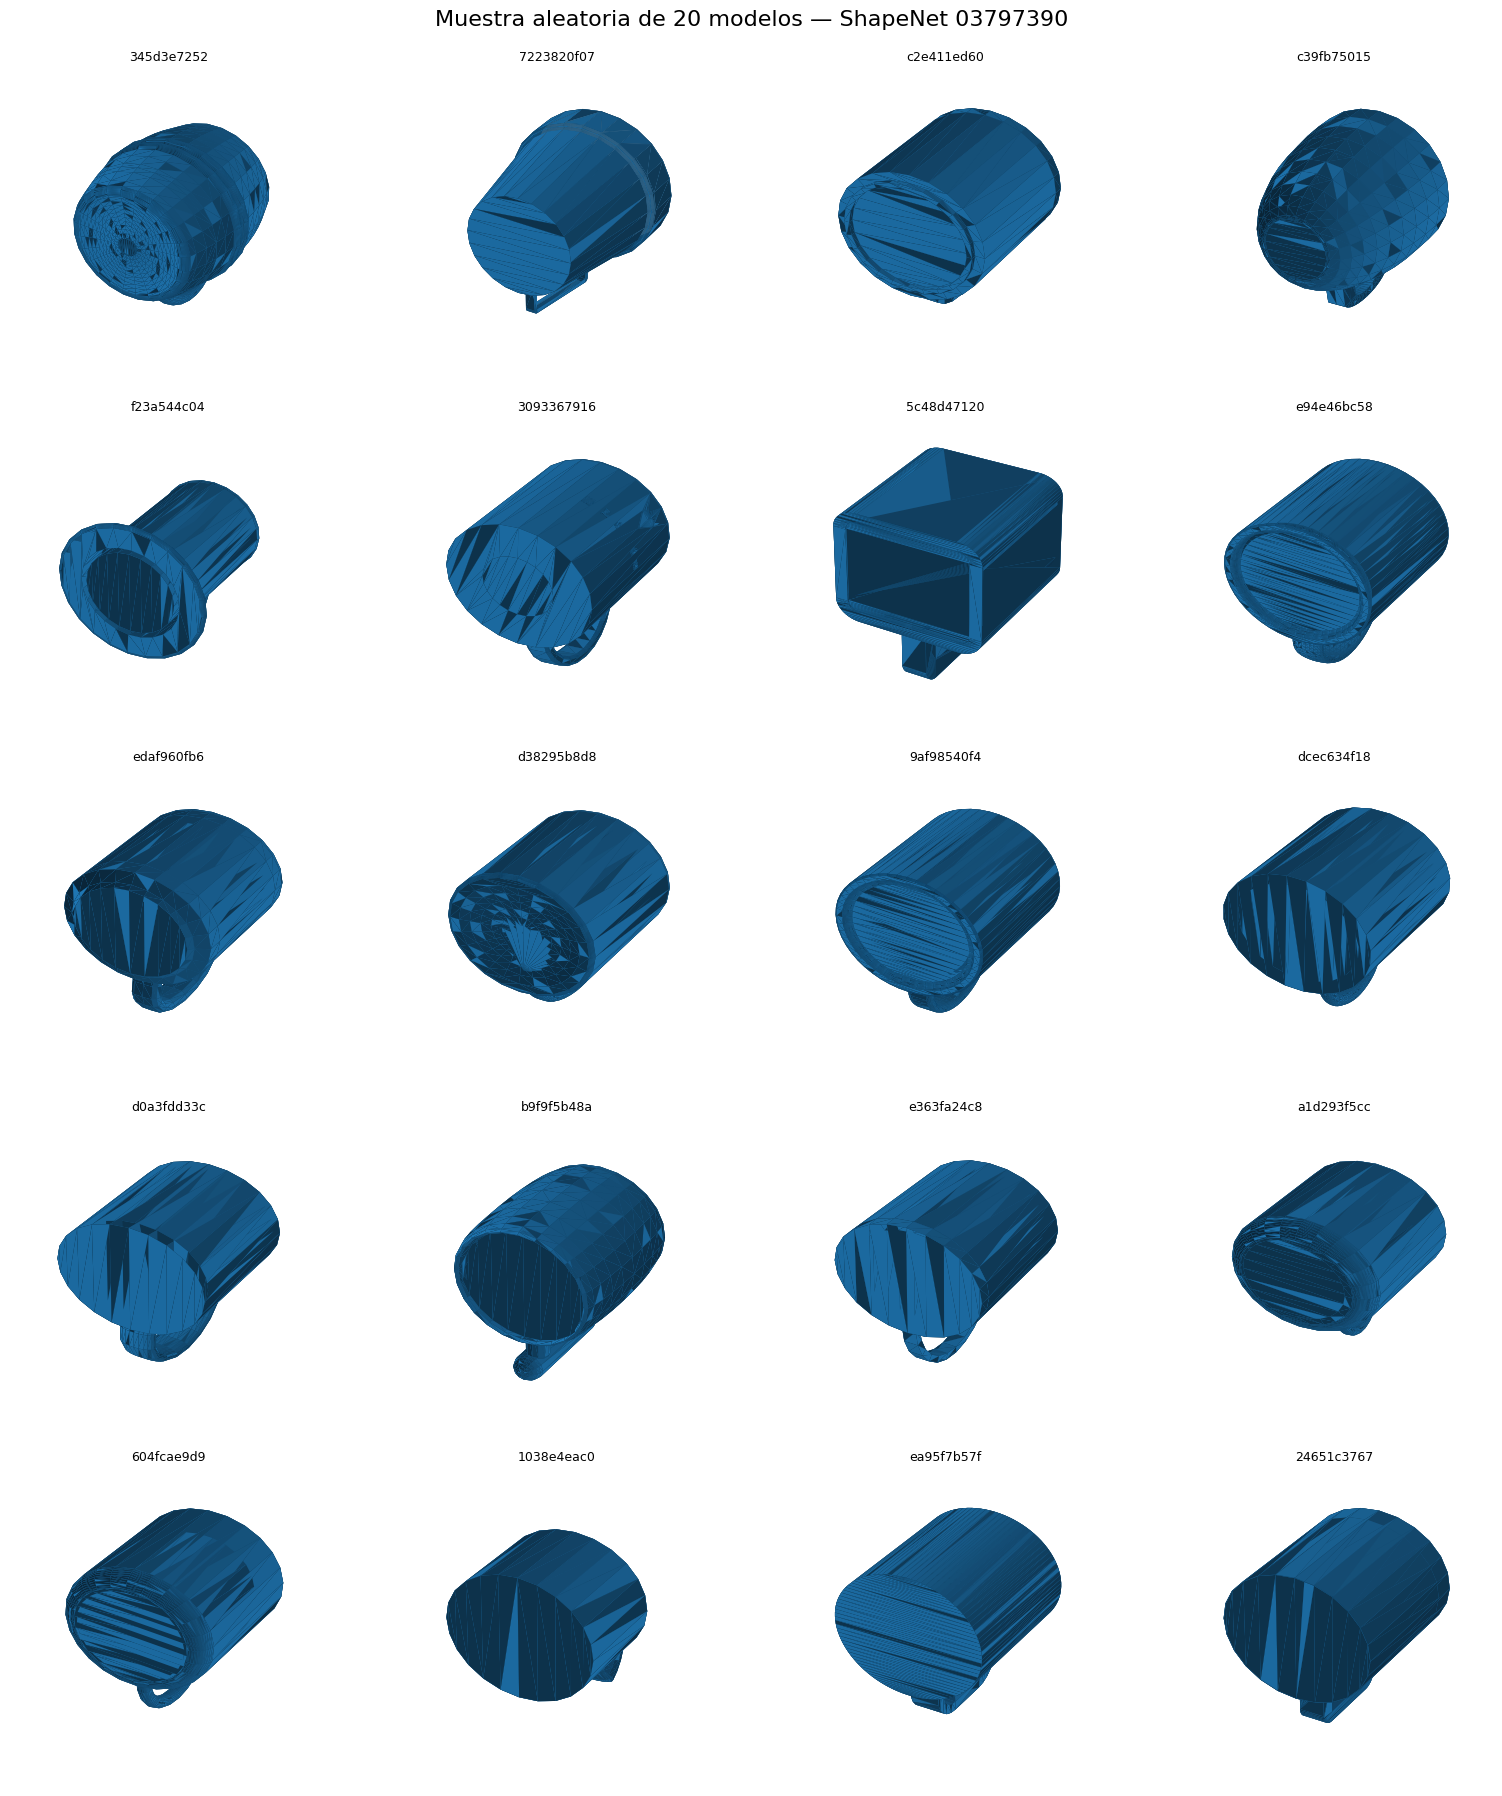

In [ ]:
# ============================================================
# 2. INSPECCIÓN VISUAL — 20 MODELOS ALEATORIOS
# ============================================================

N_MUESTRA = min(20, len(archivos_ply))
muestra = random.sample(archivos_ply, N_MUESTRA)

fig = plt.figure(figsize=(16, 18))

for i, path in enumerate(muestra):
    mesh = trimesh.load_mesh(path, process=False)

    if not isinstance(mesh, trimesh.Trimesh):
        mesh = trimesh.util.concatenate(
            tuple(mesh.geometry.values())
        )

    ax = fig.add_subplot(5, 4, i + 1, projection="3d")

    ax.plot_trisurf(
        mesh.vertices[:, 0],
        mesh.vertices[:, 1],
        mesh.vertices[:, 2],
        triangles=mesh.faces,
        linewidth=0,
        antialiased=True
    )

    ax.set_title(path.stem[:10], fontsize=9)
    ax.set_axis_off()

    # Evita el error de set_box_aspect con arrays read-only
    ax.set_box_aspect((1, 1, 1))

plt.suptitle(
    "Muestra aleatoria de 20 modelos — ShapeNet 03797390",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.show()

## 3. Generación de roturas sintéticas aleatorias y visualización de muestras

En esta sección aplicamos cortes por plano con orientaciones y posiciones aleatorias sobre cada modelo `.ply` original.

Para garantizar variabilidad real pero controlar que la pieza siga siendo reconocible como taza parcialmente destruida, la función valida que la geometría resultante conserve entre el **25% y el 85%** de los vértices originales. Si un corte aleatorio destruye por completo el objeto o casi no lo afecta, se descarta y se reintenta automáticamente.

Guardamos los archivos resultantes en la carpeta `ply` de salida y mostramos una muestra aleatoria de 20 tazas rotas para verificar la diversidad de fracturas (cortes en asa, boca, base, cortes diagonales y transversales).

/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:550: RuntimeWarning: divide by zero encountered in divide
  inverse_denominator = 1.0 / (dot00 * dot11 - dot01 * dot01)
/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:553: RuntimeWarning: invalid value encountered in multiply
  barycentric[:, 2] = (dot00 * dot12 - dot01 * dot02) * inverse_denominator
/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:554: RuntimeWarning: invalid value encountered in multiply
  barycentric[:, 1] = (dot11 * dot02 - dot01 * dot12) * inverse_denominator
/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:555: RuntimeWarning: invalid value encountered in subtract
  barycentric[:, 0] = 1 - barycentric[:, 1] - barycentric[:, 2]


✓ Generadas y guardadas 172 geometrías rotas en: /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_sintetic_rotas_v2/03797390/ply
✓ Ratio promedio de malla conservada: 60.36%


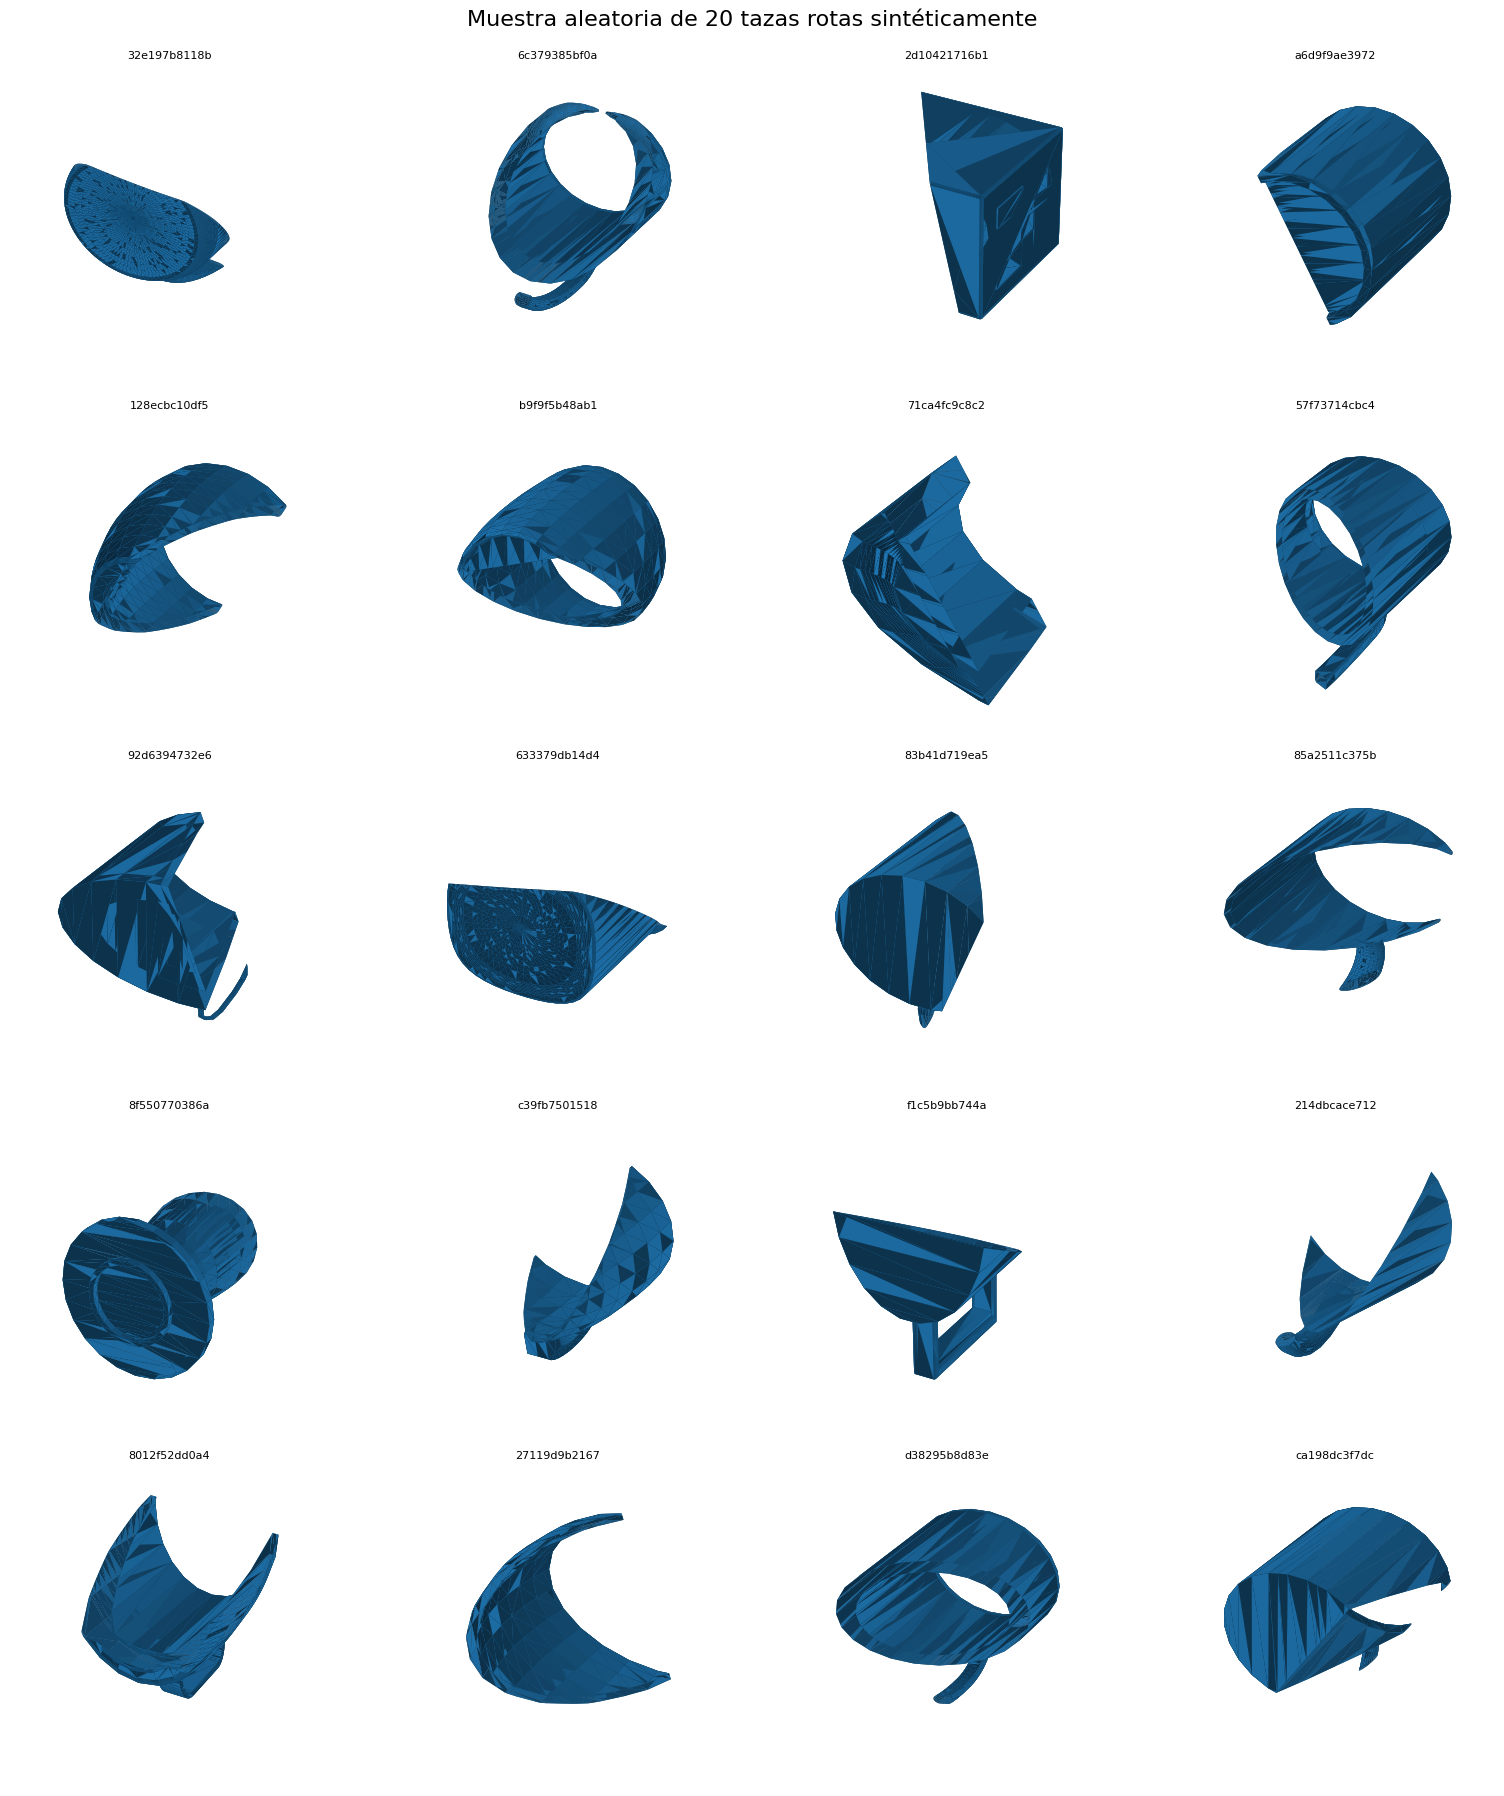

In [ ]:
# ============================================================
# 3. GENERACIÓN DE ROTURAS SINTÉTICAS Y VISUALIZACIÓN (20 MUESTRAS)
# ============================================================

def generar_rotura_aleatoria(mesh, ratio_min=0.25, ratio_max=0.85, max_intentos=15):
    """Slices a mesh with a random 3D plane, keeping between ratio_min and ratio_max of vertices."""
    extents = mesh.extents
    centroid = mesh.centroid
    for _ in range(max_intentos):
        normal = np.random.normal(size=3)
        if np.linalg.norm(normal) == 0:
            continue
        normal /= np.linalg.norm(normal)
        origin = centroid + np.random.uniform(-0.35, 0.35, size=3) * extents
        broken = mesh.slice_plane(plane_origin=origin, plane_normal=-normal)
        if isinstance(broken, trimesh.Trimesh) and not broken.is_empty:
            ratio = len(broken.vertices) / max(len(mesh.vertices), 1)
            if ratio_min <= ratio <= ratio_max:
                return broken, ratio
    # Fallback si agota intentos: corte diagonal estandarizado
    broken = mesh.slice_plane(plane_origin=centroid, plane_normal=[-0.5, -1.0, -0.5])
    ratio = len(broken.vertices) / max(len(mesh.vertices), 1) if isinstance(broken, trimesh.Trimesh) else 1.0
    return broken, ratio

# 1. Generar y exportar geometrías rotas
N_VARIANTES_POR_TAZA = 1  # Aumentar si se desea mayor volumen de datos de test
tazas_rotas_info = []

for path_ply in archivos_ply:
    mesh = trimesh.load_mesh(path_ply, process=False)
    if not isinstance(mesh, trimesh.Trimesh):
        mesh = trimesh.util.concatenate(tuple(mesh.geometry.values()))

    for v in range(N_VARIANTES_POR_TAZA):
        sufijo = f"_roto_v{v+1}" if N_VARIANTES_POR_TAZA > 1 else "_roto"
        out_name = f"{path_ply.stem}{sufijo}.ply"
        out_path = RUTA_PLY / out_name

        broken_mesh, ratio = generar_rotura_aleatoria(mesh)
        broken_mesh.export(out_path)

        tazas_rotas_info.append({
            "id_original": path_ply.stem,
            "path_roto": out_path,
            "vertices_original": len(mesh.vertices),
            "vertices_roto": len(broken_mesh.vertices),
            "ratio_conservado": ratio
        })

df_rotas = pd.DataFrame(tazas_rotas_info)
print(f"✓ Generadas y guardadas {len(df_rotas)} geometrías rotas en: {RUTA_PLY}")
print(f"✓ Ratio promedio de malla conservada: {df_rotas['ratio_conservado'].mean():.2%}")

# 2. Inspección visual de 20 muestras aleatorias
archivos_rotos_ply = sorted(RUTA_PLY.glob("*.ply"))
muestra_rotas = random.sample(archivos_rotos_ply, min(20, len(archivos_rotos_ply)))

fig = plt.figure(figsize=(16, 18))
for i, path in enumerate(muestra_rotas):
    m_broken = trimesh.load_mesh(path, process=False)
    if not isinstance(m_broken, trimesh.Trimesh):
        m_broken = trimesh.util.concatenate(tuple(m_broken.geometry.values()))

    ax = fig.add_subplot(5, 4, i + 1, projection="3d")
    ax.plot_trisurf(
        m_broken.vertices[:, 0], m_broken.vertices[:, 1], m_broken.vertices[:, 2],
        triangles=m_broken.faces, linewidth=0, antialiased=True
    )
    ax.set_title(f"{path.stem[:12]}", fontsize=8)
    ax.set_axis_off()
    ax.set_box_aspect((1, 1, 1))

plt.suptitle("Muestra aleatoria de 20 tazas rotas sintéticamente", fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

## 4. Renderizado de las cinco vistas con BlenderProc

En esta sección generamos las capturas 2D de los modelos `.ply` con las roturas sintéticas. Para mantener la compatibilidad estricta con la evaluación del checkpoint de **Pix2Vox++/A**, renderizamos cinco vistas de cámara en formato PNG de 224 x 224 píxeles con fondo transparente:

* **Vista 00:** Azimut 0°, Elevación 20° (`00.png`)
* **Vista 05:** Azimut 225°, Elevación 20° (`05.png`)
* **Vista 10:** Azimut 90°, Elevación 40° (`10.png`)
* **Vista 14:** Azimut 270°, Elevación 40° (`14.png`)
* **Vista 19:** Azimut 270°, Elevación 60° (`19.png`)

Se utiliza **BlenderProc** para asegurar la misma distancia focal (50 mm), radio de cámara (2.2) y esquema de iluminación que en el conjunto de prueba original.

In [ ]:
# ============================================================
# 4. RENDERIZADO DE LAS 5 VISTAS PIX2VOX++
# ============================================================

import json
import os
from pathlib import Path
from textwrap import dedent
import subprocess
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Configuración de las 5 vistas
# ------------------------------------------------------------

VISTAS_5_CONFIG = [
    {'view_id': 0,  'filename': '00.png', 'azimuth_deg': 0.0,   'elevation_deg': 20.0},
    {'view_id': 5,  'filename': '05.png', 'azimuth_deg': 225.0, 'elevation_deg': 20.0},
    {'view_id': 10, 'filename': '10.png', 'azimuth_deg': 90.0,  'elevation_deg': 40.0},
    {'view_id': 14, 'filename': '14.png', 'azimuth_deg': 270.0, 'elevation_deg': 40.0},
    {'view_id': 19, 'filename': '19.png', 'azimuth_deg': 270.0, 'elevation_deg': 60.0},
]

# Nombres de los archivos PNG esperados para dar por completado un renderizado
ARCHIVOS_ESPERADOS = [v['filename'] for v in VISTAS_5_CONFIG]

RUTA_VISTAS_JSON = RUTA_SALIDA / "camera_views_5.json"

with open(RUTA_VISTAS_JSON, "w", encoding="utf-8") as f:
    json.dump(VISTAS_5_CONFIG, f, indent=4)

# ------------------------------------------------------------
# 2. Worker de BlenderProc
# ------------------------------------------------------------

SCRIPT_RENDER_PATH = Path("/content/render_5v_worker.py")

SCRIPT_RENDER_CODE = dedent(r"""
import blenderproc as bproc
import argparse, json
from pathlib import Path
import imageio.v3 as iio
import numpy as np

parser = argparse.ArgumentParser()
parser.add_argument('--ply', required=True)
parser.add_argument('--views-json', required=True)
parser.add_argument('--output-dir', required=True)
parser.add_argument('--width', type=int, default=224)
parser.add_argument('--height', type=int, default=224)
parser.add_argument('--focal-length', type=float, default=50.0)
parser.add_argument('--radius', type=float, default=2.2)
args = parser.parse_args()

out_dir = Path(args.output_dir)
out_dir.mkdir(parents=True, exist_ok=True)

with open(args.views_json, 'r', encoding='utf-8') as f:
    vistas = json.load(f)

bproc.init()

objects = bproc.loader.load_obj(args.ply)

if len(objects) == 0:
    raise RuntimeError("No se pudo cargar el archivo PLY.")

obj = objects[0]

for poly in obj.get_mesh().polygons:
    poly.use_smooth = True

mat = bproc.material.create("mat_neutro")
mat.set_principled_shader_value(
    "Base Color", [0.7, 0.7, 0.7, 1.0]
)
mat.set_principled_shader_value(
    "Roughness", 0.4
)

obj.replace_materials(mat)

bproc.camera.set_intrinsics_from_blender_params(
    lens=args.focal_length,
    lens_unit="MILLIMETERS",
    image_width=args.width,
    image_height=args.height
)

bbox_center = obj.get_bound_box().mean(axis=0)

for v in vistas:

    az = np.deg2rad(float(v['azimuth_deg']))
    el = np.deg2rad(float(v['elevation_deg']))

    cam_pos = bbox_center + np.array([
        args.radius * np.cos(el) * np.cos(az),
        args.radius * np.sin(el),
        args.radius * np.cos(el) * np.sin(az)
    ])

    fwd = bbox_center - cam_pos
    fwd /= np.linalg.norm(fwd)

    up_world = np.array([0., 1., 0.])
    right = np.cross(up_world, fwd)

    if np.linalg.norm(right) < 1e-5:
        right = np.array([1., 0., 0.])
    else:
        right /= np.linalg.norm(right)

    up = np.cross(fwd, right)
    up /= np.linalg.norm(up)

    rot_mat = np.column_stack((right, up, -fwd))

    T = bproc.math.build_transformation_mat(
        cam_pos, rot_mat
    )

    bproc.camera.add_camera_pose(T)

# ------------------------------------------------------------
# Iluminación
# ------------------------------------------------------------

for i, (p_pos, p_energy) in enumerate([
    ([2.5, -2.5, 3.5], 250),
    ([-2.0, 1.5, 2.5], 140),
    ([0.5, 2.5, 3.0], 100)
]):

    light = bproc.types.Light(
        light_type="POINT",
        name=f"light_{i}"
    )

    light.set_location(p_pos)
    light.set_energy(p_energy)

# ------------------------------------------------------------
# Render
# ------------------------------------------------------------

bproc.renderer.set_output_format(
    file_format="PNG",
    color_depth=8,
    enable_transparency=True
)

bproc.renderer.set_max_amount_of_samples(32)

data = bproc.renderer.render(
    keys_with_alpha_channel={'colors'}
)

for v, img in zip(vistas, data['colors']):
    iio.imwrite(
        out_dir / v['filename'],
        img
    )
""")

SCRIPT_RENDER_PATH.write_text(
    SCRIPT_RENDER_CODE,
    encoding="utf-8"
)

# ------------------------------------------------------------
# 3. Renderizado de todos los modelos
# ------------------------------------------------------------

archivos_rotos_ply = sorted(RUTA_PLY.glob("*.ply"))

total = len(archivos_rotos_ply)
procesados = 0
omitidos = 0
errores = 0

print(f"\nModelos encontrados: {total}")
print("Iniciando renderizado...\n")

with tqdm(
    archivos_rotos_ply,
    desc="Renderizando tazas",
    unit="taza",
    dynamic_ncols=True
) as barra:

    for p_ply in barra:

        id_taza = p_ply.stem
        out_render_dir = RUTA_RENDERS / id_taza / "rendering"

        # --------------------------------------------
        # Verificación: Si ya existen las 5 vistas exactas, se omite
        # --------------------------------------------
        if out_render_dir.exists():
            vistas_existentes = [f.name for f in out_render_dir.glob("*.png")]
            if all(f in vistas_existentes for f in ARCHIVOS_ESPERADOS):
                omitidos += 1
                barra.set_postfix(
                    procesados=procesados,
                    omitidas=omitidos,
                    errores=errores
                )
                continue

        # --------------------------------------------
        # Renderizar si falta algún archivo
        # --------------------------------------------

        out_render_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        cmd = [
            "blenderproc",
            "run",
            str(SCRIPT_RENDER_PATH),
            "--ply",
            str(p_ply),
            "--views-json",
            str(RUTA_VISTAS_JSON),
            "--output-dir",
            str(out_render_dir)
        ]

        env = os.environ.copy()
        env["MPLBACKEND"] = "Agg"

        res = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            env=env
        )

        if res.returncode != 0:
            errores += 1
            print(f"\n❌ Error renderizando {id_taza}:")
            print(res.stderr[-500:])
        else:
            procesados += 1

        barra.set_postfix(
            procesados=procesados,
            omitidas=omitidos,
            errores=errores
        )

print("\n" + "=" * 60)
print("RENDERIZADO COMPLETADO")
print("=" * 60)
print(f"Modelos totales:  {total}")
print(f"Renderizados:     {procesados}")
print(f"Omitidos:         {omitidos}")
print(f"Errores:          {errores}")
print(f"Salida:           {RUTA_RENDERS}")


Modelos encontrados: 172
Iniciando renderizado...



Renderizando tazas:   0%|          | 0/172 [00:00<?, ?taza/s]


RENDERIZADO COMPLETADO
Modelos totales:  172
Renderizados:     0
Omitidos:         172
Errores:          0
Salida:           /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_sintetic_rotas_v2/03797390/renders_5v


## 5. Visualización de las 5 vistas renderizadas y la geometría 3D

En esta sección se realiza una inspección visual de una muestra aleatoria de 12 tazas rotas del dataset sintético generado:

1. **Vistas 2D:** Muestra de las 5 imágenes renderizadas (`00.png`, `05.png`, `10.png`, `14.png`, `19.png`) que servirán de entrada al modelo Pix2Vox++.
2. **Superficie 3D limpia:** Visualización interactiva con `Plotly` (`go.Mesh3d`) renderizando una superficie continua lisa, sin líneas de triangulación, para apreciar la morfología real de cada rotura.

In [ ]:
# ============================================================
# 5. VISUALIZACIÓN DE 12 MUESTRAS ALEATORIAS (2D Y 3D)
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import trimesh
from PIL import Image

# 1. Selección aleatoria de 12 muestras
archivos_rotos_ply = sorted(RUTA_PLY.glob("*.ply"))
NUM_MUESTRAS = min(12, len(archivos_rotos_ply))
muestras_id = random.sample([p.stem for p in archivos_rotos_ply], NUM_MUESTRAS)

# 2. Render 2D de las 5 vistas en grilla
fig, axes = plt.subplots(len(muestras_id), 5, figsize=(15, 2.8 * len(muestras_id)))

for r_idx, m_id in enumerate(muestras_id):
    dir_renders = RUTA_RENDERS / m_id / "rendering"
    for c_idx, v in enumerate(VISTAS_5_CONFIG):
        ax = axes[r_idx, c_idx] if len(muestras_id) > 1 else axes[c_idx]
        img_path = dir_renders / v['filename']

        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)

        if r_idx == 0:
            ax.set_title(f"Vista {v['filename']}\n({v['azimuth_deg']}°, {v['elevation_deg']}°)", fontsize=8)

        ax.axis('off')

    ax_first = axes[r_idx, 0] if len(muestras_id) > 1 else axes[0]
    ax_first.text(-0.25, 0.5, f"ID: {m_id[:8]}", transform=ax_first.transAxes,
                  rotation=90, va='center', ha='right', fontweight='bold', fontsize=9)

plt.suptitle(f"5 Vistas Renderizadas — Muestra de {len(muestras_id)} Tazas Rotas", fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

# 3. Mallas 3D limpias interactivas (Plotly)
for m_id in muestras_id:
    ply_path = RUTA_PLY / f"{m_id}.ply"
    if not ply_path.exists():
        continue

    mesh_sample = trimesh.load_mesh(ply_path, process=False)
    if not isinstance(mesh_sample, trimesh.Trimesh):
        mesh_sample = trimesh.util.concatenate(tuple(mesh_sample.geometry.values()))

    fig_3d = go.Figure(data=[
        go.Mesh3d(
            x=mesh_sample.vertices[:, 0],
            y=mesh_sample.vertices[:, 1],
            z=mesh_sample.vertices[:, 2],
            i=mesh_sample.faces[:, 0],
            j=mesh_sample.faces[:, 1],
            k=mesh_sample.faces[:, 2],
            color='steelblue',
            opacity=1.0,
            lighting=dict(ambient=0.5, diffuse=0.8, fresnel=0.2, specular=0.5, roughness=0.4)
        )
    ])

    fig_3d.update_layout(
        title=f"Malla 3D Limpia (Plotly) — {m_id[:12]}",
        scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False), aspectmode='data'),
        width=550, height=450,
        margin=dict(l=10, r=10, b=10, t=40)
    )
    fig_3d.show()

Output hidden; open in https://colab.research.google.com to view.

## 6. Catálogo de tazas rotas y carga de Pix2Vox++

Se construye el catálogo emparejando cada malla `.ply` rota con sus cinco vistas renderizadas (`00`, `05`, `10`, `14`, `19`), descartando cualquier taza cuyo renderizado no se haya completado. A continuación se carga el mismo checkpoint finetuneado que se usó para evaluar Fantastik Break (`exp13_7categorias_5v_finetuning_mejor.pth`), junto con el umbral de binarización seleccionado en su día sobre el conjunto de validación.

In [ ]:
# ============================================================
# 6. CATÁLOGO DE TAZAS ROTAS + CARGA DE PIX2VOX++
# ============================================================
import sys, torch
from scipy.spatial import cKDTree
from scipy.ndimage import binary_dilation, binary_erosion
from skimage.measure import marching_cubes

# ------------------------------------------------------------
# 6.1 Catálogo: para cada .ply roto, comprobar que existen las 5 vistas
# ------------------------------------------------------------
ARCHIVOS_ESPERADOS_MAP = {v['view_id']: v['filename'] for v in VISTAS_5_CONFIG}  # {0:'00.png', 5:'05.png', ...}

registros_catalogo = []
for p_ply in sorted(RUTA_PLY.glob("*.ply")):
    id_taza = p_ply.stem
    dir_render = RUTA_RENDERS / id_taza / "rendering"
    vistas_ok = {f"vista_{vid:02d}": dir_render / fn for vid, fn in ARCHIVOS_ESPERADOS_MAP.items()}
    if all(p.exists() for p in vistas_ok.values()):
        registros_catalogo.append({"identificador": id_taza, "ply_roto": p_ply, **vistas_ok})

df_inferencia = pd.DataFrame(registros_catalogo)
COLUMNAS_VISTAS = [f"vista_{vid:02d}" for vid in ARCHIVOS_ESPERADOS_MAP]

print(f"Tazas rotas con 5 vistas completas: {len(df_inferencia)} / {len(list(RUTA_PLY.glob('*.ply')))}")

# ------------------------------------------------------------
# 6.2 Rutas de salida de esta fase
# ------------------------------------------------------------
RUTA_BINVOX_PRED = RUTA_BINVOX / "pred"
RUTA_BINVOX_GT   = RUTA_BINVOX / "gt"
RUTA_PRED_MALLA  = RUTA_SALIDA / "predicciones_pix2vox_malla"
for r in [RUTA_BINVOX_PRED, RUTA_BINVOX_GT, RUTA_PRED_MALLA]:
    r.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 6.3 Cargar modelo Pix2Vox++ (mismo checkpoint que FantastikBreak §18)
# ------------------------------------------------------------
RUTA_NOTEBOOKS = Path("/content/drive/MyDrive/Colab Notebooks")
if str(RUTA_NOTEBOOKS) not in sys.path:
    sys.path.append(str(RUTA_NOTEBOOKS))

from modelo_pix2vox import Pix2VoxPlusPlusA, cargar_checkpoint_finetuning, DEVICE

NOMBRE_EXPERIMENTO_INFERENCIA = "exp13_7categorias_5v_finetuning_mejor.pth"
RUTA_CHECKPOINT_INFERENCIA = RUTA_BASE / "E2/Pix2Vox++/checkpoints" / NOMBRE_EXPERIMENTO_INFERENCIA
if not RUTA_CHECKPOINT_INFERENCIA.exists():
    raise FileNotFoundError(f"No se encuentra:\n{RUTA_CHECKPOINT_INFERENCIA}")

modelo_pix2vox = Pix2VoxPlusPlusA(usar_refiner=True, usar_merger=True, usar_pesos_imagenet=False)
meta_ckpt = cargar_checkpoint_finetuning(modelo=modelo_pix2vox, ruta_checkpoint=RUTA_CHECKPOINT_INFERENCIA,
                                          dispositivo_carga="cpu", estricto=True)
if meta_ckpt["claves_ausentes"] or meta_ckpt["claves_inesperadas"]:
    raise RuntimeError("El checkpoint no coincide con la arquitectura.")

modelo_pix2vox = modelo_pix2vox.to(DEVICE)
modelo_pix2vox.eval()

UMBRAL_VOXEL = float(meta_ckpt["mejor_umbral"])
TAMANO_IMAGEN = 224
MEDIA_IMAGEN = np.array([0.5, 0.5, 0.5], dtype=np.float32)
DESVIACION_IMAGEN = np.array([0.5, 0.5, 0.5], dtype=np.float32)

print("Checkpoint:", NOMBRE_EXPERIMENTO_INFERENCIA)
print("IoU validación del checkpoint:", meta_ckpt["mejor_iou_validacion"])
print("Threshold:", UMBRAL_VOXEL, "| Dispositivo:", DEVICE)

Tazas rotas con 5 vistas completas: 172 / 172
Checkpoint: exp13_7categorias_5v_finetuning_mejor.pth
IoU validación del checkpoint: 0.6545949246951499
Threshold: 0.3 | Dispositivo: cuda


## 7. Ground truth voxel, inferencia y métricas de superficie

Esta sección reúne todo lo necesario para evaluar el modelo:

* **Lector/escritor `.binvox`**, con el mismo reordenamiento de ejes interno `x-z-y → x-y-z` que usa `leer_binvox` en el notebook de entrenamiento de Pix2Vox++, para que los archivos generados aquí sean directamente compatibles con ese pipeline.
* **Ground truth**: a diferencia de Fantastik Break (que partía de una nube de puntos reconstruida con BPA), aquí la rotura ya es una malla `.ply` limpia real, así que se voxeliza directamente su superficie en el cubo `[0,1]³` con `pitch = 1/32`.
* **Inferencia**: las cinco vistas de cada taza rota se pasan por Pix2Vox++ exactamente con el mismo preprocesado (224×224, normalización a `[-1,1]`) que se usó en entrenamiento.
* **Métricas**: IoU, Dice, precisión y recall de superficie, más las versiones con tolerancia de 1 vóxel — las mismas métricas definidas en la sección 5 del notebook de entrenamiento.

Se recorren todas las tazas rotas, guardando por cada una el `.binvox` predicho, el `.binvox` del ground truth y la malla `.ply` reconstruida, y se vuelca todo en un CSV de métricas.

In [ ]:
# ============================================================
# 7. UTILIDADES BINVOX + INFERENCIA + VOXEL GT + MÉTRICAS
# ============================================================

# ------------------------------------------------------------
# 7.1 Lector/escritor binvox estándar (orden de eje x,z,y — convención binvox/Pix2Vox)
# ------------------------------------------------------------
from PIL import Image
def escribir_binvox(volumen, ruta, translate=(0.0, 0.0, 0.0), scale=1.0):
    vol = np.asarray(volumen, dtype=bool)
    dim = vol.shape[0]
    flat = np.transpose(vol, (0, 2, 1)).flatten()
    with open(ruta, "wb") as f:
        f.write(b"#binvox 1\n")
        f.write(f"dim {dim} {dim} {dim}\n".encode())
        f.write(f"translate {translate[0]} {translate[1]} {translate[2]}\n".encode())
        f.write(f"scale {scale}\n".encode())
        f.write(b"data\n")
        n, i = len(flat), 0
        while i < n:
            valor, cuenta = flat[i], 1
            while i + cuenta < n and flat[i + cuenta] == valor and cuenta < 255:
                cuenta += 1
            f.write(bytes([int(valor), cuenta]))
            i += cuenta

def leer_binvox(ruta):
    with open(ruta, "rb") as f:
        linea = f.readline().decode("ascii", errors="replace").strip()
        if not linea.startswith("#binvox"):
            raise ValueError(f"No es un binvox válido: {ruta}")
        dims = translate = scale = None
        while True:
            linea = f.readline().decode("ascii", errors="replace").strip()
            if linea.startswith("data"):
                break
            partes = linea.split()
            if not partes:
                continue
            if partes[0] == "dim":
                dims = tuple(int(v) for v in partes[1:4])
            elif partes[0] == "translate":
                translate = tuple(float(v) for v in partes[1:4])
            elif partes[0] == "scale":
                scale = float(partes[1])
        raw = f.read()
    if dims is None:
        raise ValueError(f"Cabecera binvox incompleta: {ruta}")
    pares = np.frombuffer(raw, dtype=np.uint8).reshape(-1, 2)
    vol = np.repeat(pares[:, 0], pares[:, 1]).astype(bool).reshape((dims[0],) * 3)
    return np.transpose(vol, (0, 2, 1))

# ------------------------------------------------------------
# 7.2 GT voxel: usa el translate/scale del binvox ORIGINAL (taza completa)
#     para normalizar el .ply roto al mismo cubo [0,1]³ que usó Pix2Vox++
# ------------------------------------------------------------
import re

RUTA_VOXELES_ORIGINALES = RUTA_BASE / "E2/Datos_E2_voxel/03797390"

def leer_cabecera_binvox(ruta_binvox):
    """Lee solo dim/translate/scale de un binvox (sin descomprimir los datos)."""
    with open(ruta_binvox, "rb") as f:
        linea = f.readline().decode("ascii").strip()
        if not linea.startswith("#binvox"):
            raise ValueError(f"No es un binvox válido: {ruta_binvox}")
        dims = translate = scale = None
        while True:
            linea = f.readline().decode("ascii").strip()
            if linea.startswith("data"):
                break
            partes = linea.split()
            if partes and partes[0] == "dim":
                dims = tuple(int(v) for v in partes[1:4])
            elif partes and partes[0] == "translate":
                translate = tuple(float(v) for v in partes[1:4])
            elif partes and partes[0] == "scale":
                scale = float(partes[1])
    if dims is None or translate is None or scale is None:
        raise ValueError(f"Cabecera binvox incompleta: {ruta_binvox}")
    return dims, translate, scale

def identificador_original(identificador_roto):
    """Quita el sufijo '_roto' o '_roto_vN' para recuperar el ID de ShapeNet."""
    return re.sub(r"_roto(_v\d+)?$", "", identificador_roto)

def ply_roto_a_voxel_32(ruta_ply, translate, scale, resolucion=RESOLUCION_VOXEL):
    """Voxeliza la SUPERFICIE del .ply roto, normalizando con el translate/scale
    del binvox original de la taza completa (mismo cubo que vio Pix2Vox++)."""
    mesh = trimesh.load(ruta_ply, force="mesh", process=False)
    if not isinstance(mesh, trimesh.Trimesh) or mesh.is_empty:
        raise ValueError(f"Malla vacía o inválida: {ruta_ply}")

    translate = np.asarray(translate, dtype=np.float64)

    def normalizar(puntos):
        return (np.asarray(puntos, dtype=np.float64) - translate) / scale

    pitch_local = scale / float(resolucion)  # pitch en el espacio ORIGINAL de la malla
    vg = mesh.voxelized(pitch=pitch_local, method="subdivide")
    puntos = np.vstack([normalizar(vg.points), normalizar(mesh.vertices)])

    volumen = np.zeros((resolucion,) * 3, dtype=bool)
    puntos = np.clip(puntos, 0.0, 1.0 - 1e-10)
    idx = np.floor(puntos * resolucion).astype(np.int32)
    validos = np.all((idx >= 0) & (idx < resolucion), axis=1)
    idx = idx[validos]
    volumen[idx[:, 0], idx[:, 1], idx[:, 2]] = True
    return volumen
def ply_roto_a_voxel_32_relleno(ruta_ply, translate, scale, resolucion=RESOLUCION_VOXEL):
    """Voxeliza el VOLUMEN relleno (no solo la superficie) del .ply roto,
    comparable al IoU volumétrico estándar usado en entrenamiento."""
    mesh = trimesh.load(ruta_ply, force="mesh", process=False)
    if not isinstance(mesh, trimesh.Trimesh) or mesh.is_empty:
        raise ValueError(f"Malla vacía o inválida: {ruta_ply}")
    pitch_local = scale / float(resolucion)
    vg = mesh.voxelized(pitch=pitch_local, method="subdivide")
    if mesh.is_watertight:
        vg = vg.fill()  # rellena el interior si la malla está cerrada
    translate = np.asarray(translate, dtype=np.float64)
    puntos = (np.asarray(vg.points, dtype=np.float64) - translate) / scale
    volumen = np.zeros((resolucion,) * 3, dtype=bool)
    puntos = np.clip(puntos, 0.0, 1.0 - 1e-10)
    idx = np.floor(puntos * resolucion).astype(np.int32)
    validos = np.all((idx >= 0) & (idx < resolucion), axis=1)
    idx = idx[validos]
    volumen[idx[:, 0], idx[:, 1], idx[:, 2]] = True
    return volumen

def metricas_voxel_volumetrico(pred_volumen, gt_volumen):
    """IoU/Dice volumétrico estándar (sin restringir a superficie)."""
    pred = np.asarray(pred_volumen, dtype=bool)
    gt = np.asarray(gt_volumen, dtype=bool)
    inter = int(np.logical_and(pred, gt).sum())
    union = int(np.logical_or(pred, gt).sum())
    n_pred, n_gt = int(pred.sum()), int(gt.sum())
    return {
        "iou_volumetrico": inter / union if union > 0 else np.nan,
        "dice_volumetrico": 2.0 * inter / (n_pred + n_gt) if (n_pred + n_gt) > 0 else np.nan,
        "precision_volumetrica": inter / n_pred if n_pred > 0 else np.nan,
        "recall_volumetrico": inter / n_gt if n_gt > 0 else np.nan,
    }
# ------------------------------------------------------------
# 7.3 Preparación de imagen + carga de vistas (idéntico a FantastikBreak §19)
# ------------------------------------------------------------
def cargar_imagen_pix2vox(ruta_imagen, color_fondo=(240/255, 240/255, 240/255)):
    with Image.open(ruta_imagen) as imagen:
        imagen = imagen.convert("RGBA").resize((TAMANO_IMAGEN, TAMANO_IMAGEN), resample=Image.Resampling.BILINEAR)
        imagen_rgba = np.asarray(imagen, dtype=np.float32) / 255.0
    rgb = imagen_rgba[:, :, :3]
    alpha = imagen_rgba[:, :, 3:4]
    fondo = np.asarray(color_fondo, dtype=np.float32).reshape(1, 1, 3)
    rgb = rgb * alpha + fondo * (1.0 - alpha)
    bgr = rgb[:, :, ::-1].copy()  # el modelo espera BGR, no RGB
    bgr = (bgr - MEDIA_IMAGEN) / DESVIACION_IMAGEN
    return torch.from_numpy(np.transpose(bgr, (2, 0, 1)).copy()).float()

def cargar_imagenes_fila(fila):
    imgs = [cargar_imagen_pix2vox(fila[col]) for col in COLUMNAS_VISTAS]
    return torch.stack(imgs, dim=0).unsqueeze(0).to(DEVICE)

def preparar_imagen_visualizacion(ruta_imagen, color_fondo=(240/255, 240/255, 240/255)):
    """Solo para mostrar en pantalla — RGB, sin normalizar, mismo fondo que usa el modelo."""
    with Image.open(ruta_imagen) as im:
        rgba = im.convert("RGBA").resize((TAMANO_IMAGEN, TAMANO_IMAGEN), resample=Image.Resampling.BILINEAR)
        rgba = np.asarray(rgba, dtype=np.float32) / 255.0
    rgb, alpha = rgba[:, :, :3], rgba[:, :, 3:4]
    fondo = np.asarray(color_fondo, dtype=np.float32).reshape(1, 1, 3)
    return np.clip(rgb * alpha + fondo * (1.0 - alpha), 0.0, 1.0)


@torch.inference_mode()
def inferir_voxel_pix2vox(fila):
    salida = modelo_pix2vox(cargar_imagenes_fila(fila))
    voxel_prob = salida["volumen_final"].squeeze().detach().cpu().numpy().astype(np.float32)
    if voxel_prob.shape != (RESOLUCION_VOXEL,) * 3:
        raise RuntimeError(f"Shape inesperado: {voxel_prob.shape}")
    return voxel_prob

def voxel_binario_a_malla(volumen_binario):
    volumen = np.asarray(volumen_binario, dtype=bool)
    if volumen.sum() == 0:
        return None
    vol_pad = np.pad(volumen.astype(np.float32), 1, mode="constant")
    verts, caras, _, _ = marching_cubes(vol_pad, level=0.5)
    verts = np.clip((verts - 1.0 + 0.5) / RESOLUCION_VOXEL, 0.0, 1.0)
    return trimesh.Trimesh(vertices=verts, faces=caras, process=False)

# ------------------------------------------------------------
# 7.4 Métricas superficie-vs-superficie (idéntico a FantastikBreak §19)
# ------------------------------------------------------------
def extraer_superficie_voxel(volumen):
    volumen = np.asarray(volumen, dtype=bool)
    if volumen.sum() == 0:
        return volumen.copy()
    erosionado = binary_erosion(volumen, structure=np.ones((3, 3, 3), dtype=bool), border_value=0)
    return volumen & ~erosionado

def metricas_voxel(pred_volumen, gt_superficie):
    pred = extraer_superficie_voxel(np.asarray(pred_volumen, dtype=bool))
    gt = np.asarray(gt_superficie, dtype=bool)
    inter = int(np.logical_and(pred, gt).sum())
    union = int(np.logical_or(pred, gt).sum())
    n_pred, n_gt = int(pred.sum()), int(gt.sum())
    iou = inter / union if union > 0 else np.nan
    precision = inter / n_pred if n_pred > 0 else np.nan
    recall = inter / n_gt if n_gt > 0 else np.nan
    dice = 2.0 * inter / (n_pred + n_gt) if (n_pred + n_gt) > 0 else np.nan
    estr = np.ones((3, 3, 3), dtype=bool)
    gt_dil = binary_dilation(gt, structure=estr, iterations=1)
    pred_dil = binary_dilation(pred, structure=estr, iterations=1)
    precision_tol = np.logical_and(pred, gt_dil).sum() / n_pred if n_pred > 0 else np.nan
    recall_tol = np.logical_and(gt, pred_dil).sum() / n_gt if n_gt > 0 else np.nan
    f1_tol = (2 * precision_tol * recall_tol / (precision_tol + recall_tol)
              if np.isfinite(precision_tol) and np.isfinite(recall_tol) and (precision_tol + recall_tol) > 0 else np.nan)
    return {"iou_voxel_roto": float(iou), "dice_voxel_roto": float(dice),
            "precision_voxel_roto": float(precision), "recall_voxel_roto": float(recall),
            "precision_voxel_tolerancia_1": float(precision_tol), "recall_voxel_tolerancia_1": float(recall_tol),
            "f1_voxel_tolerancia_1": float(f1_tol),
            "voxeles_predichos_volumen": int(pred_volumen.astype(bool).sum()),
            "voxeles_predichos_superficie": n_pred, "voxeles_gt_roto": n_gt, "voxeles_interseccion": inter}



# Sanity check: la taza COMPLETA (sin romper) voxelizada con este método
# debería casi coincidir con su propio model.binvox de entrenamiento.
for ident_test in df_inferencia["identificador"].sample(3, random_state=SEMILLA):
    ident_orig = identificador_original(ident_test)
    ruta_bv_original = RUTA_VOXELES_ORIGINALES / ident_orig / "model.binvox"
    ruta_ply_original = RUTA_ORIGINALES / f"{ident_orig}.ply"
    if not ruta_bv_original.exists() or not ruta_ply_original.exists():
        print(f"{ident_orig}: falta binvox u original, se omite el check"); continue
    dims, translate, scale = leer_cabecera_binvox(ruta_bv_original)
    voxel_reconstruido = ply_roto_a_voxel_32(ruta_ply_original, translate, scale)
    voxel_entrenamiento = leer_binvox(ruta_bv_original)  # tu propio lector, mismo orden de ejes
    inter = np.logical_and(voxel_reconstruido, voxel_entrenamiento).sum()
    union = np.logical_or(voxel_reconstruido, voxel_entrenamiento).sum()
    print(f"{ident_orig}: IoU superficie-vs-volumen = {inter/union:.3f}  (esperado: claramente > 0, no exacto porque uno es volumen y otro superficie)")



# ------------------------------------------------------------
# 7.5 Ejecutar sobre todas las tazas rotas
# ------------------------------------------------------------
np.random.seed(SEMILLA)
resultados_voxel = []
primer_error_mostrado = False

for _, fila in tqdm(df_inferencia.iterrows(), total=len(df_inferencia), desc="Pix2Vox++ — inferencia + métricas"):
    ident = fila["identificador"]
    try:
        voxel_prob = inferir_voxel_pix2vox(fila)
        voxel_bin = voxel_prob >= UMBRAL_VOXEL
        escribir_binvox(voxel_bin, RUTA_BINVOX_PRED / f"{ident}.binvox")

        ident_orig = identificador_original(ident)
        ruta_bv_original = RUTA_VOXELES_ORIGINALES / ident_orig / "model.binvox"
        _, translate, scale = leer_cabecera_binvox(ruta_bv_original)
        gt_voxel = ply_roto_a_voxel_32(fila["ply_roto"], translate, scale)
        escribir_binvox(gt_voxel, RUTA_BINVOX_GT / f"{ident}.binvox")

        mesh_pred = voxel_binario_a_malla(voxel_bin)
        if mesh_pred is None:
            resultados_voxel.append({"identificador": ident, "estado": "prediccion_vacia"})
            continue
        ruta_malla_pred = RUTA_PRED_MALLA / f"{ident}.ply"
        mesh_pred.export(ruta_malla_pred)

        gt_voxel_relleno = ply_roto_a_voxel_32_relleno(fila["ply_roto"], translate, scale)
        mets_vol = metricas_voxel_volumetrico(voxel_bin, gt_voxel_relleno)  # sin extraer_superficie_voxel: comparamos volumen completo predicho vs volumen relleno del roto

        mets = metricas_voxel(voxel_bin, gt_voxel)
        resultados_voxel.append({"identificador": ident, "estado": "ok",
                                  "ruta_binvox_pred": str(RUTA_BINVOX_PRED / f"{ident}.binvox"),
                                  "ruta_binvox_gt": str(RUTA_BINVOX_GT / f"{ident}.binvox"),
                                  "ruta_malla_pred": str(ruta_malla_pred),
                                  "ratio_conservado": df_rotas.loc[df_rotas["path_roto"].astype(str).str.contains(ident), "ratio_conservado"].iloc[0]
                                      if "df_rotas" in dir() else np.nan,
                                  "translate": translate, "scale": scale, **mets, **mets_vol})



        mets = metricas_voxel(voxel_bin, gt_voxel)
        resultados_voxel.append({"identificador": ident, "estado": "ok",
                                  "ruta_binvox_pred": str(RUTA_BINVOX_PRED / f"{ident}.binvox"),
                                  "ruta_binvox_gt": str(RUTA_BINVOX_GT / f"{ident}.binvox"),
                                  "ruta_malla_pred": str(ruta_malla_pred),
                                  "translate": translate, "scale": scale, **mets})
    except Exception as exc:
        if not primer_error_mostrado:
            import traceback; print(f"\n--- Primer error ({ident}) ---"); traceback.print_exc()
            primer_error_mostrado = True
        resultados_voxel.append({"identificador": ident, "estado": "error", "error": f"{type(exc).__name__}: {exc}"})

df_metricas_voxel = pd.DataFrame(resultados_voxel)
RUTA_METRICAS_VOXEL = RUTA_METADATA / "evaluacion_pix2vox_voxel_tazas_rotas.csv"
df_metricas_voxel.to_csv(RUTA_METRICAS_VOXEL, index=False)
df_ok = df_metricas_voxel[df_metricas_voxel["estado"] == "ok"].copy()
print("=" * 75); print("MÉTRICAS 3D — SUPERFICIE VOXEL 32³ (tazas rotas sintéticas)"); print("=" * 75)
if len(df_ok):
    display(df_ok[["iou_voxel_roto", "dice_voxel_roto", "precision_voxel_roto", "recall_voxel_roto",
                    "f1_voxel_tolerancia_1", "voxeles_predichos_superficie", "voxeles_gt_roto"]].describe())
else:
    print("¡Ninguna taza procesada correctamente! Revisa 'df_metricas_voxel[\"error\"]'.")
print(f"\nVálidas: {len(df_ok)} / {len(df_metricas_voxel)}  |  CSV: {RUTA_METRICAS_VOXEL}")

5582a89be131867846ebf4f1147c3f0f: IoU superficie-vs-volumen = 0.176  (esperado: claramente > 0, no exacto porque uno es volumen y otro superficie)
4f9f31db3c3873692a6f53dd95fd4468: IoU superficie-vs-volumen = 0.107  (esperado: claramente > 0, no exacto porque uno es volumen y otro superficie)
9196f53a0d4be2806ffeedd41ba624d6: IoU superficie-vs-volumen = 0.241  (esperado: claramente > 0, no exacto porque uno es volumen y otro superficie)


Pix2Vox++ — inferencia + métricas:   0%|          | 0/172 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274: RuntimeWarning:

invalid value encountered in cast

/usr/local/lib/python3.12/dist-packages/trimesh/grouping.py:274:

MÉTRICAS 3D — SUPERFICIE VOXEL 32³ (tazas rotas sintéticas)


,iou_voxel_roto,dice_voxel_roto,precision_voxel_roto,recall_voxel_roto,f1_voxel_tolerancia_1,voxeles_predichos_superficie,voxeles_gt_roto
count,344.000000,344.000000,344.000000,344.000000,292.000000,344.000000,344.000000
mean,0.044243,0.082082,0.082315,0.086931,0.242247,2161.616279,1956.075581
std,0.039325,0.070741,0.074011,0.075779,0.145137,1134.911385,938.181530
min,0.000000,0.000000,0.000000,0.000000,0.001354,143.000000,302.000000
25%,0.003974,0.007917,0.007856,0.007129,0.118569,1223.500000,1294.000000
50%,0.043787,0.083896,0.074591,0.085946,0.248310,2008.500000,1878.500000
75%,0.071640,0.133700,0.131533,0.144122,0.344511,2841.750000,2510.000000
max,0.186489,0.314354,0.316810,0.311936,0.677639,5744.000000,4995.000000



Válidas: 344 / 344  |  CSV: /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_sintetic_rotas_v2/03797390/metadata/evaluacion_pix2vox_voxel_tazas_rotas.csv


## 8. Comparación visual: 5 imágenes + reconstrucción vs rotura real

Inspección cualitativa sobre una muestra aleatoria de 20 tazas rotas: para cada una se muestran las cinco imágenes exactas que recibe el modelo y, debajo, la malla reconstruida por Pix2Vox++ junto a la malla de la rotura real (ground truth), con el IoU, Dice y F1 de superficie en el título. Sirve para contrastar visualmente si las métricas numéricas se corresponden con reconstrucciones razonables.

In [ ]:
# ============================================================
# 8. COMPARACIÓN VISUAL: 5 IMÁGENES + MALLA PREDICHA VS GT ROTO
# ============================================================
N_VISUAL = 20
df_visual = df_ok.sample(n=min(N_VISUAL, len(df_ok)), random_state=SEMILLA).reset_index(drop=True)

display(df_visual[["identificador", "iou_voxel_roto", "dice_voxel_roto",
                    "precision_voxel_roto", "recall_voxel_roto", "f1_voxel_tolerancia_1"]])

for _, res in df_visual.iterrows():
    ident = res["identificador"]
    fila = df_inferencia[df_inferencia["identificador"] == ident].iloc[0]

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 5, height_ratios=[1, 2.2], hspace=0.20)

    for j, col in enumerate(COLUMNAS_VISTAS):
        ax = fig.add_subplot(gs[0, j])
        ax.imshow(preparar_imagen_visualizacion(fila[col]))
        ax.set_title(col.replace("vista_", "Vista "))
        ax.axis("off")

    ax3d = fig.add_subplot(gs[1, :3], projection="3d")
    mesh_pred = trimesh.load(res["ruta_malla_pred"], force="mesh", process=False)
    v, c = np.asarray(mesh_pred.vertices), np.asarray(mesh_pred.faces)
    ax3d.plot_trisurf(v[:, 0], v[:, 2], v[:, 1], triangles=c, linewidth=0.05, color="steelblue")
    ax3d.set_xlim(0, 1); ax3d.set_ylim(0, 1); ax3d.set_zlim(0, 1); ax3d.set_box_aspect((1, 1, 1))
    ax3d.view_init(elev=20, azim=-60); ax3d.set_title("Predicción Pix2Vox++")

    ax3d_gt = fig.add_subplot(gs[1, 3:], projection="3d")
    mesh_gt = trimesh.load(fila["ply_roto"], force="mesh", process=False)
    vg_ = (np.asarray(mesh_gt.vertices, dtype=np.float64) - np.asarray(res["translate"], dtype=np.float64)) / res["scale"]
    cg_ = np.asarray(mesh_gt.faces)
    ax3d_gt.plot_trisurf(vg_[:, 0], vg_[:, 2], vg_[:, 1], triangles=cg_, linewidth=0.05, color="indianred")
    ax3d_gt.set_xlim(0, 1); ax3d_gt.set_ylim(0, 1); ax3d_gt.set_zlim(0, 1); ax3d_gt.set_box_aspect((1, 1, 1))
    ax3d_gt.view_init(elev=20, azim=-60); ax3d_gt.set_title("Taza rota real (GT)")

    fig.suptitle(f"{ident}   |   IoU={res['iou_voxel_roto']:.4f}   |   Dice={res['dice_voxel_roto']:.4f}"
                 f"   |   F1 tol.1={res['f1_voxel_tolerancia_1']:.4f}", fontsize=14)
    plt.tight_layout(); plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 9. Resumen agregado de generalización

Distribución de IoU, Dice y F-score de superficie sobre el conjunto completo de tazas rotas sintéticas, junto con los peores casos (los que más podrían delatar una mala generalización del modelo a geometrías rotas que no vio en entrenamiento). La conversión a `.npy` queda pendiente hasta confirmar, con estas métricas y la inspección visual, que el modelo generaliza bien.

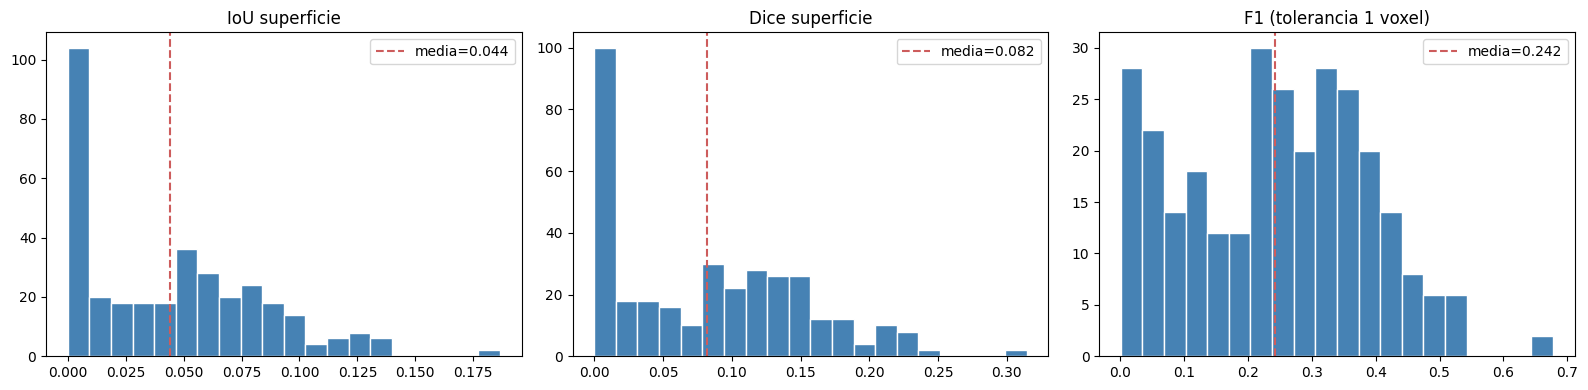

Peores 5 casos (posible indicio de mala generalización):


,identificador,iou_voxel_roto,dice_voxel_roto
6,1305b9266d38eb4d9f818dd0aa1a251_roto,0.0,0.0
7,1305b9266d38eb4d9f818dd0aa1a251_roto,0.0,0.0
14,17952a204c0a9f526c69dceb67157a66_roto,0.0,0.0
15,17952a204c0a9f526c69dceb67157a66_roto,0.0,0.0
20,1ae1ba5dfb2a085247df6165146d5bbd_roto,0.0,0.0



NOTA: este IoU es superficie-vs-superficie sobre tazas rotas sintéticas y no debe compararse
numéricamente con el IoU volumétrico de ShapeNet completo usado en entrenamiento/test.
Conversión a .npy: pendiente, solo si estas métricas y la inspección visual confirman buena generalización.


/tmp/ipykernel_3760/1056888835.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,iou_voxel_roto,iou_volumetrico,dice_volumetrico
tramo_rotura,,,
muy severa (<40%),0.036,0.044,0.081
severa (40-60%),0.038,0.046,0.083
leve (60-85%),0.050,0.061,0.110
mínima (>85%),NaN,NaN,NaN


       iou_voxel_roto  iou_volumetrico  dice_volumetrico  recall_volumetrico
count         344.000          172.000           172.000             172.000
mean            0.044            0.054             0.098               0.144
std             0.039            0.051             0.089               0.144
min             0.000            0.000             0.000               0.000
25%             0.004            0.003             0.006               0.007
50%             0.044            0.047             0.089               0.122
75%             0.072            0.091             0.167               0.225
max             0.186            0.202             0.336               0.733


In [ ]:
# ============================================================
# 9. RESUMEN AGREGADO — ¿GENERALIZA BIEN PIX2VOX++?
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, titulo in zip(axes, ["iou_voxel_roto", "dice_voxel_roto", "f1_voxel_tolerancia_1"],
                            ["IoU superficie", "Dice superficie", "F1 (tolerancia 1 voxel)"]):
    ax.hist(df_ok[col].dropna(), bins=20, color="steelblue", edgecolor="white")
    ax.axvline(df_ok[col].mean(), color="indianred", linestyle="--", label=f"media={df_ok[col].mean():.3f}")
    ax.set_title(titulo); ax.legend()
plt.tight_layout(); plt.show()

print("Peores 5 casos (posible indicio de mala generalización):")
display(df_ok.nsmallest(5, "iou_voxel_roto")[["identificador", "iou_voxel_roto", "dice_voxel_roto"]])

print("\nNOTA: este IoU es superficie-vs-superficie sobre tazas rotas sintéticas y no debe compararse")
print("numéricamente con el IoU volumétrico de ShapeNet completo usado en entrenamiento/test.")
print("Conversión a .npy: pendiente, solo si estas métricas y la inspección visual confirman buena generalización.")

if "ratio_conservado" in df_ok.columns and df_ok["ratio_conservado"].notna().any():
    df_ok["tramo_rotura"] = pd.cut(df_ok["ratio_conservado"], bins=[0, 0.4, 0.6, 0.85, 1.0],
                                     labels=["muy severa (<40%)", "severa (40-60%)", "leve (60-85%)", "mínima (>85%)"])
    display(df_ok.groupby("tramo_rotura")[["iou_voxel_roto", "iou_volumetrico", "dice_volumetrico"]].mean().round(3))

print(df_ok[["iou_voxel_roto", "iou_volumetrico", "dice_volumetrico", "recall_volumetrico"]].describe().round(3))